<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Fourier-transform" data-toc-modified-id="Fourier-transform-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Fourier transform</a></span><ul class="toc-item"><li><span><a href="#Convolution-in-the-Fourier-domain" data-toc-modified-id="Convolution-in-the-Fourier-domain-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Convolution in the Fourier domain</a></span></li><li><span><a href="#Hybrid-images" data-toc-modified-id="Hybrid-images-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Hybrid images</a></span></li></ul></li></ul></li><li><span><a href="#Light-Field-Methods" data-toc-modified-id="Light-Field-Methods-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Light Field Methods</a></span><ul class="toc-item"><li><span><a href="#Reading-and-displaying-light-fields" data-toc-modified-id="Reading-and-displaying-light-fields-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Reading and displaying light fields</a></span><ul class="toc-item"><li><span><a href="#Get-light-field-data" data-toc-modified-id="Get-light-field-data-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Get light field data</a></span></li><li><span><a href="#Reading-the-light-field" data-toc-modified-id="Reading-the-light-field-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>Reading the light field</a></span></li><li><span><a href="#Displaying-the-center-sub-aperture-image-(SAI)" data-toc-modified-id="Displaying-the-center-sub-aperture-image-(SAI)-2.1.3"><span class="toc-item-num">2.1.3&nbsp;&nbsp;</span>Displaying the center sub aperture image (SAI)</a></span></li><li><span><a href="#Display-different-SAIs" data-toc-modified-id="Display-different-SAIs-2.1.4"><span class="toc-item-num">2.1.4&nbsp;&nbsp;</span>Display different SAIs</a></span></li><li><span><a href="#Synthesize-a-full-aperture-image" data-toc-modified-id="Synthesize-a-full-aperture-image-2.1.5"><span class="toc-item-num">2.1.5&nbsp;&nbsp;</span>Synthesize a full aperture image</a></span></li></ul></li><li><span><a href="#Refocusing-with-light-fields" data-toc-modified-id="Refocusing-with-light-fields-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Refocusing with light fields</a></span></li><li><span><a href="#Focus-stack" data-toc-modified-id="Focus-stack-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Focus stack</a></span></li><li><span><a href="#Mitsuba-plugin-for-light-field-camera" data-toc-modified-id="Mitsuba-plugin-for-light-field-camera-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Mitsuba plugin for light field camera</a></span></li><li><span><a href="#Schlieren-imaging" data-toc-modified-id="Schlieren-imaging-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Schlieren imaging</a></span><ul class="toc-item"><li><span><a href="#Quantitative-measurement-of-deflection-angles" data-toc-modified-id="Quantitative-measurement-of-deflection-angles-2.5.1"><span class="toc-item-num">2.5.1&nbsp;&nbsp;</span>Quantitative measurement of deflection angles</a></span></li><li><span><a href="#Mitsuba-plugin-for-schlieren-sensor" data-toc-modified-id="Mitsuba-plugin-for-schlieren-sensor-2.5.2"><span class="toc-item-num">2.5.2&nbsp;&nbsp;</span>Mitsuba plugin for schlieren sensor</a></span></li></ul></li><li><span><a href="#Light-field-displays" data-toc-modified-id="Light-field-displays-2.6"><span class="toc-item-num">2.6&nbsp;&nbsp;</span>Light field displays</a></span></li></ul></li></ul></div>

In [1]:
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy.signal as sig
from scipy.integrate import simpson
from IPython.display import SVG, display, IFrame, HTML
#%matplotlib notebook
%matplotlib widget
book = False
from scipy import ndimage
from scipy import misc

## Fourier transform

### Convolution in the Fourier domain

Implement a function `fourier_conv(img:np.ndarray, kernel:np.ndarray) -> np.ndarray` that performs a 2D-convolution of the input image `img` with the convolution kernel `kernel` in the Fourier domain.

Validate via the function `np.allclose` and an example image that your result is equal to the result when performing the convolution in the spatial domain with `scipy.ndimage.convolve`.

In [2]:
def pad_like(inp : np.ndarray, like : np.ndarray):
    to_pad = tuple(np.int32((np.array(like.shape) - np.array(inp.shape))/2))
    return np.pad(inp, ((to_pad[0], to_pad[0]), (to_pad[1], to_pad[1])))

In [3]:
def fourier_conv(img:np.ndarray, kernel:np.ndarray) -> np.ndarray:
    
    img_fft = np.fft.fft2(img)
    
    kernel_padded = pad_like(kernel, img)
    kernel_padded_fft = np.fft.fft2(np.fft.ifftshift(kernel_padded))
    
    result = np.real(np.fft.ifft2(img_fft * kernel_padded_fft))
    
        
    return result

In [4]:
def fourier_conv(img:np.ndarray, kernel:np.ndarray) -> np.ndarray:
    
    result = np.zeros_like(img) ## replace with your solution
    
    return result

Test your function:

<ipython-input-5-bac6696ebc26>:1: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  img = np.float32(misc.face(gray=True))[0:-1, 0:-1]


Is your solution correct: False


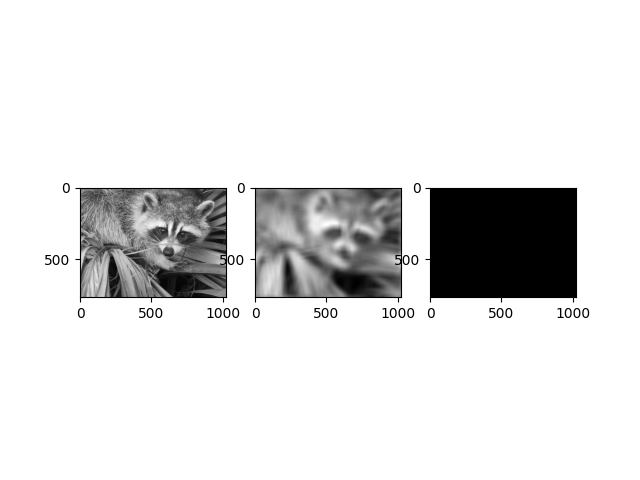

In [5]:
img = np.float32(misc.face(gray=True))[0:-1, 0:-1]
kernel = np.ones((51,51))

res_fourier = fourier_conv(img, kernel)
res_spatial = ndimage.convolve(img, kernel, mode='wrap') ## Which mode do you have to use?

print(f"Is your solution correct: {np.allclose(res_fourier, res_spatial)}")

plt.figure()

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(res_spatial, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(res_fourier, cmap='gray')

In [6]:
img = np.float32(misc.face(gray=True))[0:-1, 0:-1]
kernel = np.ones((51,51))

res_fourier = fourier_conv(img, kernel)
res_spatial = ndimage.convolve(img, kernel, mode='???') ## Which mode do you have to use?

print(f"Is your solution correct: {np.allclose(res_fourier, res_spatial)}")

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(res_spatial, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(res_fourier, cmap='gray')

<ipython-input-6-2e2f87a661ce>:1: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  img = np.float32(misc.face(gray=True))[0:-1, 0:-1]


RuntimeError: boundary mode not supported

### Hybrid images

Read the paper

*Hybrid images* by Aude Oliva et al. (https://dl.acm.org/doi/abs/10.1145/1141911.1141919).

Implement a function that takes two input images and combines them by high pass-filtering the first one and low pass-filtering the second one, so that in the resulting images, the first original image can be seen when viewing from a close distance and the second original image can be seen from a far distance.

In [ ]:
def make_odd_shapes(inp : np.ndarray) -> np.ndarray:
    if (inp.shape[0] % 2 == 0):
        inp = inp[0:-1,:]
    if (inp.shape[1] % 2 == 0):
        inp = inp[:,0:-1]
    return inp

In [ ]:
img1 = misc.face(gray=True)[0:-1, 0:-1]
img2 = pad_like(make_odd_shapes(cv2.cvtColor(plt.imread("figures/ex1/Hund.jpg"), cv2.COLOR_RGB2GRAY)), img1)

In [ ]:
img1.shape, img2.shape

In [ ]:
plt.figure()
plt.imshow(img1, cmap='gray')

In [ ]:
def createPillobxResponse(r, x_size, y_size):
    X,Y = np.meshgrid(np.arange(-1*np.floor(x_size/2),np.floor(x_size/2)+1,1), np.arange(-1*np.floor(y_size/2),np.floor(y_size/2)+1,1))
    psf = np.zeros_like(X)
    psf[np.sqrt(X**2+Y**2) <= r] = 1
    return psf, X, Y

In [ ]:
def create_hybrid_image(ratio):
    
    kernel, _, _ = createPillobxResponse(ratio * min(img1.shape[0], img1.shape[1]) / 2, img1.shape[1], img1.shape[0])

    img1_fft = np.fft.fftshift(np.fft.fft2(img1))
    img2_fft = np.fft.fftshift(np.fft.fft2(img2))

    kernel_padded = pad_like(kernel, img1_fft)

    img_res_fft = kernel_padded * img1_fft + (np.ones_like(kernel_padded) - kernel_padded) * img2_fft

    img_res = np.real(np.fft.ifft2(np.fft.ifftshift(img_res_fft)))
    
    #plt.imshow(kernel_padded)
    plt.imshow(img_res, cmap='gray')
    

In [ ]:
plt.figure()
interact(lambda i: create_hybrid_image(i), i=widgets.FloatSlider(min=0.01, max=0.2, step=0.01, value=0.01))

# Light Field Methods

## Reading and displaying light fields

### Get light field data

Download the HCI light field dataset (see 'A dataset and evaluation methodology for depth estimation on 4D light fields' by Honauer et al.) from https://lightfield-analysis.uni-konstanz.de/

### Reading the light field

Read light field from the bedroom scene from the HCI dataset and convert it into a 4D-structure `lf(m,n,j,k)` with `(m,n)` denoting the spatial coordinates and `(j,k)` denoting the angular coordinates.

In [ ]:
test = plt.imread(f"{path}input_Cam000.png")

In [ ]:
test.dtype, test.max(), test.min()

In [ ]:
path = 'figures/3/bedroom/'

tmp = cv2.cvtColor(np.uint8(255*plt.imread(f"{path}input_Cam000.png")), cv2.COLOR_RGB2GRAY)
lf = np.zeros((tmp.shape[0], tmp.shape[1], 9, 9), dtype = 'uint8')
for j in range(0,9):
    for k in range(0,9):
        imgStr = str(j*9+k)
        while len(imgStr) < 3:
            imgStr = f"0{imgStr}"
        curImg = cv2.cvtColor(np.uint8(255*plt.imread(f"{path}input_Cam{imgStr}.png")), cv2.COLOR_RGB2GRAY)
        lf[:,:,j,k] = curImg

In [ ]:
def imshow(img, cmap=None):
    plt.close('all')
    plt.figure()
    plt.imshow(img, cmap=cmap)
    plt.show()

In [ ]:
def imshow2(img, cmap=None):
    #plt.close('all')
    #plt.figure()
    plt.clf()
    plt.imshow(img, cmap=cmap)
    #plt.show()

### Displaying the center sub aperture image (SAI)

Show center SAI for $\mathbf{j}=(4,4)^\intercal$:

In [ ]:
imshow(lf[:,:,4,4], cmap='gray')

### Display different SAIs

Visualize how the perspective changes when the horizontal angular coordinate is changed continuosly.

In [ ]:
lf_tmp = lf.copy()

In [ ]:
plt.figure()
interact(lambda j: imshow2(lf[:,:,4,j], cmap='gray'), j=widgets.IntSlider(min=0,max=8, step=1, value=4))

### Synthesize a full aperture image

Synthesize full aperture image, i.e., $g(\mathbf{m})=\sum\limits_{\mathbf{j}\in\Omega_\mathrm{a}} L(\mathbf{m},\mathbf{j})\,$:

In [ ]:
imshow(np.sum(np.sum(lf,axis=2),axis=2), cmap='gray')

## Refocusing with light fields

Define a refocus function `refocus(alpha)` by means of the shift and add-method as shown in the lecture.

Hint: To realize the shift-operation, have a look at OpenCV whether there is a suitable function.

In [ ]:
def refocus(alpha):
    refocused = np.zeros_like(lf[:,:,0,0])
    refocused = np.float32(refocused)

    for v in range(0,lf.shape[2]):
        for u in range(0,lf.shape[3]):
            curShift = np.array([[1, 0, (u-4)*(1-1/alpha)],
                                 [0, 1, (v-4)*(1-1/alpha)]], dtype='float32')
            curSAI = np.float32(lf[:,:,v,u])
            curSAIShifted = cv2.warpAffine(curSAI, curShift, (curSAI.shape[1], curSAI.shape[0]))

            refocused = refocused + curSAIShifted
    
    return refocused

Visualize the refocusing results for different $\alpha$, e.g., for $\alpha \in $ `np.arange(0.4,3.0,0.2)`:

In [ ]:
plt.figure()
interact(lambda alpha: imshow2(np.uint8(refocus(alpha)/81),cmap='gray'), alpha=widgets.FloatSlider(min=0.4,max=1.3, step=0.05, value=1.0))

## Focus stack

We will now calculate a single all-in-focus image of the observed scene.<br>
For that purpose, first create a stack of refocused images for the $\alpha$-values used above. Then try to filter each image of this series with a filter, that highlights sharp image regions, i.e., image regions with high spatial frequencies. For every pixel position, find the image inside the stack that is most sharp at that position. Eventually, extract for every pixel position the pixel value of the focal stack image that exhibits the highest sharpness for that position in order to obtain the all-in-focus image.

In [ ]:
steps = np.arange(0.4,3.0,0.2)

focus_stack = np.zeros((lf.shape[0],lf.shape[1], len(steps)))

In [ ]:
for i, alpha in enumerate(steps):
    focus_stack[:,:,i] = refocus(alpha)

In [ ]:
log = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])

In [ ]:
plt.figure()
plt.imshow(log)

In [ ]:
imshow(np.abs(ndimage.convolve(refocus(1.5), log)))

In [ ]:
log_stack = np.zeros_like(focus_stack)
for i in range(0, focus_stack.shape[2]):
    log_stack[:,:,i] = np.abs(ndimage.convolve(focus_stack[:,:,i], log))

In [ ]:
fusion_map = np.argmax(log_stack,2)

In [ ]:
imshow(fusion_map)

In [ ]:
fused_image = np.zeros((lf.shape[0], lf.shape[1]))
for i in range(0, focus_stack.shape[2]):
    fused_image[fusion_map == i] = focus_stack[fusion_map == i, i]

In [ ]:
imshow(fused_image, cmap = 'gray')

## Mitsuba plugin for light field camera

Implement a Mitsuba plugin that realizes a light field camera based on a micro-lens array as introduced in the lecture. Assume circular lenses and no crosstalk. Save the light field as a single spatially multiplexed image.

In [ ]:
#variant = "scalar_rgb"
#variant = "cuda_ad_rgb"
variant = "llvm_ad_rgb"

import os as os
os.environ["MI_DEFAULT_VARIANT"] = variant

import mitsuba as mi
import drjit as dr
import matplotlib.pyplot as plt

mi.set_variant(variant)

In [ ]:
class light_field_sensor (mi.Sensor):
    def __init__(self, props):
        mi.Sensor.__init__(self, props)
        self.to_world = props['to_world']
        self.foc_len  = props['foc_len']
        self.img_dist_l = props['img_dist_l']
        self.img_dist_ml = props['img_dist_ml']
        self.sen_size = props['sen_size']
        
        self.ang_res = props['ang_res']
        self.filmsize = (self.sen_size, self.sen_size)
        
        self.spat_res = self.film().size()[0] / self.ang_res
        self.ml_diam = self.sen_size / self.spat_res
        self.ml_rad = self.ml_diam / 2

        self.to_world = mi.Transform4d(self.to_world)

            
    def sample_ray_differential(self, time, sample1, sample2, sample3, active=True):
        weight = 1.0
        
        
        p_s = mi.Point3f((sample2[0]-0.5) * self.filmsize[0], (sample2[1]-0.5) * self.filmsize[1], -1.0 * self.img_dist_ml)
                
        # Which micro lens? --> determine index ml = (j,k) of corresponding micro lens
        ml = dr.floor((sample2*self.filmsize) / self.ml_diam)
                    
        # Determine coords of center of corresponding micro lens
        p_ml = mi.Point3f(ml[0] * self.ml_diam + self.ml_diam/2 - (self.spat_res * self.ml_diam) / 2, \
                          ml[1] * self.ml_diam + self.ml_diam/2 - (self.spat_res * self.ml_diam) / 2, \
                          -1 * self.img_dist_l)
        
        weight = dr.select((dr.sqrt((p_ml[0]-p_s[0])**2 + (p_ml[1]-p_s[1])**2) > self.ml_rad), 0.0, weight)
        
        #if dr.sqrt((p_ml[0]-p_s[0])**2 + (p_ml[1]-p_s[1])**2) > self.ml_rad:
        #    weight = 0.0
                
        
        # Determine point on main lens corresponding to center of micro lens
        p_l_1 = (p_ml - p_s) / self.img_dist_ml * self.img_dist_l + p_ml
        p_l_1[2] = 0.0
        

        # Determine point on main lens corresponding to aperture sample on micro lens
        p_a_2d = self.ml_rad * mi.warp.square_to_uniform_disk_concentric(sample3)
        p_a_offset = mi.Point3f(p_a_2d[0], p_a_2d[1], 0.0)
        p_l_2 = p_l_1 + p_a_offset
        
                        
        # Determine focused world point w.r.t. center of determined micro lens
        p_o = p_ml / (-1.0 * self.img_dist_l) * 1/(1/self.foc_len - 1/self.img_dist_l)
        
        
        rayd = mi.RayDifferential3f()
        rayd.has_differentials = False
        
        
        
        d = dr.normalize(mi.Vector3f(p_o - p_l_2))
                
        rayd.o = self.to_world.transform_affine(p_l_2)
        rayd.d = self.to_world @ d
        
        return (rayd, mi.Color3f(weight, weight, weight))

In [ ]:
mi.register_sensor("light_field_sensor", lambda props: light_field_sensor(props))

In [ ]:
g = 8.0
b = 12
b_ml = 4
f = 1/(1/b + 1/g)
#f,b,g,V

In [ ]:
scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'path'
    },

    'sphere' : {
        'type': 'sphere',
        'emitter': {
            'type': 'area',
            'radiance': {
            'type': 'rgb',
            'value': 0.8,
        },
    },
    'center': [0, 0, g],
    'radius': 0.7,
        
    },
    'sphere2' : {
        'type': 'sphere',
        'emitter': {
            'type': 'area',
            'radiance': {
            'type': 'rgb',
            'value': 0.8,
        },
    },
    'center': [-2, -2, g+1],
    'radius': 0.4,
        
    },
 
    'sensor': {
        'type': 'light_field_sensor',
        'to_world': mi.ScalarTransform4f.look_at(origin=[0, 0, 0],
                                                 target=[0, 0, 1],
                                                 up=[0, 1, 0]),
        'foc_len' : f,
        'img_dist_l': b,
        'img_dist_ml': b_ml,
        'sen_size': 10.0,
        'ang_res': 15,
        'film': {'type': 'hdrfilm',
      'width': 1500,
      'height': 1500,
      'rfilter': {'type': 'gaussian'},
      'pixel_format': 'rgb',
      'component_format': 'float32'},
     'sampler': {'type': 'independent', 'sample_count': 128},
    }
})

In [ ]:
scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'path'
    },

    'sphere' : {
        'type': 'sphere',
        'bsdf': {
   'type': 'plastic',
'diffuse_reflectance': {
    'type': 'rgb',
    'value': [0.1, 0.27, 0.36]
},
'int_ior': 1.9
},
    'center': [0, 0, g],
    'radius': 1.5,
        
    },
    'sphere2' : {
        'type': 'sphere',
        'bsdf': {
            'type': 'thindielectric',
'int_ior': 'bk7',
'ext_ior': 'air'
    },
    'center': [-2, -2, g],
    'radius': 0.4,
        
    },
    'emit': {
        'type': 'envmap',
        'filename': 'textures/envmap.exr'
    },
    'sensor': {
        'type': 'light_field_sensor',
        'to_world': mi.ScalarTransform4f.look_at(origin=[0, 0, 0],
                                                 target=[0, 0, 1],
                                                 up=[0, 1, 0]),
        'foc_len' : f,
        'img_dist_l': b,
        'img_dist_ml': b_ml,
        'sen_size': 10.0,
        'ang_res': 15,
        'film': {'type': 'hdrfilm',
      'width': 1500,
      'height': 1500,
      'rfilter': {'type': 'gaussian'},
      'pixel_format': 'rgb',
      'component_format': 'float32'},
     'sampler': {'type': 'independent', 'sample_count': 128},
    }
})

In [ ]:
image = mi.render(scene)

In [ ]:
np.save("ex02_lf_image", image)

In [ ]:
image = np.load("ex02_lf_image.npy")

In [ ]:
plt.figure()
plt.imshow(image, cmap='gray')

In [ ]:
image = np.array(image)
if len(image.shape) > 2:
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
lf = np.zeros((np.int32(image.shape[0]/15), np.int32(image.shape[1]/15), 15, 15))
for j in range(0,15):
    for k in range(0,15):
        curImg = image[j:image.shape[0]:15, k:image.shape[0]:15]
        lf[:,:,j,k] = curImg

In [ ]:
imshow(lf[:,:,5,5], cmap='gray')

## Schlieren imaging

### Quantitative measurement of deflection angles

In the lecture we learned:

Quantitative measurements of the deflection angle $\alpha$ are only possible if

$$ \delta_\alpha > \frac{1}{2}\varepsilon\,, $$

with $\varepsilon$ denoting the diameter of the image of the light source.

Explain why this is true.

**Answer**:<br>Since in practice, the light source can not be an ideal point light source, it will lead to light rays which do not propagate parallel to the optical axis in the measurement field. As a result, the image of the light source on the plane of the Schlieren stop also does not resemble an ideal point but some non-zero area. Any rays which are deflected by an angle $\alpha$ in the measurement field which results in a displacement $\delta_\alpha$ on the Schlieren stop, which does not exceed the area covered by the image of the light source, i.e., for which $\delta_\alpha \leq \frac{1}{2}\varepsilon$ can not be distinguished from light rays which are deflected because of the spatial extent of the light source and not because of an refractive effect in the measurement field.

### Mitsuba plugin for schlieren sensor

Implement a color-coded Schlieren setup in the Mitsuba rendering framework.

Encode the color-wheel via the HSI color space as follows:
* The angle is encoded via the hue value and
* the radius is encoded via the intensity value.

In [ ]:
from drjit.llvm import Float, Array3f, UInt

In [ ]:
import drjit as dr

def hsi_to_rgb(h, s, i):
    # h: hue in [0, 2*pi], s: saturation in [0,1], i: intensity in [0,1]
    h = h - dr.floor(h / (2 * dr.pi)) * (2 * dr.pi)
    r = dr.zeros(type(h))
    g = dr.zeros(type(h))
    b = dr.zeros(type(h))

    # Sector 0: 0 <= h < 2*pi/3
    cond0 = h < 2 * dr.pi / 3
    # Sector 1: 2*pi/3 <= h < 4*pi/3
    cond1 = (h >= 2 * dr.pi / 3) & (h < 4 * dr.pi / 3)
    # Sector 2: 4*pi/3 <= h < 2*pi
    cond2 = h >= 4 * dr.pi / 3

    # Sector 0
    r0 = i * (1 + s * dr.cos(h) / dr.cos(dr.pi / 3 - h))
    g0 = i * (1 + s * (1 - dr.cos(h) / dr.cos(dr.pi / 3 - h)))
    b0 = i * (1 - s)
    r = dr.select(cond0, r0, r)
    g = dr.select(cond0, g0, g)
    b = dr.select(cond0, b0, b)

    # Sector 1
    h1 = h - 2 * dr.pi / 3
    r1 = i * (1 - s)
    g1 = i * (1 + s * dr.cos(h1) / dr.cos(dr.pi / 3 - h1))
    b1 = i * (1 + s * (1 - dr.cos(h1) / dr.cos(dr.pi / 3 - h1)))
    r = dr.select(cond1, r1, r)
    g = dr.select(cond1, g1, g)
    b = dr.select(cond1, b1, b)

    # Sector 2
    h2 = h - 4 * dr.pi / 3
    r2 = i * (1 + s * (1 - dr.cos(h2) / dr.cos(dr.pi / 3 - h2)))
    g2 = i * (1 - s)
    b2 = i * (1 + s * dr.cos(h2) / dr.cos(dr.pi / 3 - h2))
    r = dr.select(cond2, r2, r)
    g = dr.select(cond2, g2, g)
    b = dr.select(cond2, b2, b)

    return r,g,b

In [ ]:
class color_schlieren_sensor (mi.Sensor):
    def __init__(self, props):
        mi.Sensor.__init__(self, props)
        self.to_world = props['to_world']
        self.foc_len  = props['foc_len']
        self.img_dist = props['img_dist']
        self.sen_size = props['sen_size']
        self.lens_rad = props['lens_rad']
        self.filmsize = (self.sen_size, self.sen_size)
        self.rad_max = (self.lens_rad - self.sen_size / 2) / self.img_dist * (self.img_dist - self.foc_len) + self.sen_size / 2
        self.to_world = mi.Transform4d(self.to_world)

        
    def sample_ray_differential(self, time, sample1, sample2, sample3, active=True):
        
        p_a_2d = self.lens_rad * mi.warp.square_to_uniform_disk_concentric(sample3)
        p_a = mi.Point3f(p_a_2d[0], p_a_2d[1], 0.0)
        
        p_s = mi.Point3f((sample2[0]-0.5) * self.filmsize[0], (sample2[1]-0.5) * self.filmsize[1], -1.0 * self.img_dist)
        
        p_o = p_s / (-1.0 * self.img_dist) * 1/(1/self.foc_len - 1/self.img_dist)
        
        rayd = mi.RayDifferential3f()
        rayd.has_differentials = False
        
                
        d = dr.normalize(mi.Vector3f(p_o - p_a))
                
        rayd.o = self.to_world.transform_affine(p_a)
        rayd.d = self.to_world @ d
        
        ### Calculate color wheel influence
        p_f = (p_a - p_s) / self.img_dist * (self.img_dist - self.foc_len) + p_s
        radius = dr.sqrt(p_f[0]**2 + p_f[1]**2)
        alpha = dr.atan2(p_f[1] , p_f[0])
        
        
        
        
        h = (alpha + dr.pi)
        s = Float(1.0)
        i = dr.minimum(1.0, radius/self.rad_max)
        
        r,g,b = hsi_to_rgb(h,s,i)
        
        
        
        return (rayd, mi.Color3f(r, g, b))

    
    def to_string(self):
        return ('thin_lens_sensor[\n'
                '    foc_len=%s,\n'
                '    img_dist=%s,\n'
                '    sen_size=%s,\n'
                '    lens_rad=%s,\n'
                ']' % (self.foc_len, self.img_dist, self.sen_size, self.lens_rad))
        

In [ ]:
mi.register_sensor("color_schlieren_sensor", lambda props: color_schlieren_sensor(props))

In [ ]:
class telecentric_area_light (mi.Emitter):
    def __init__(self, props):
        mi.Emitter.__init__(self, props)
        self.acc_angle = dr.deg2rad(props['acc_angle'])
        self.radiance = mi.Color3f(props['radiance'])
        self.flags = mi.EmitterFlags.Surface | mi.EmitterFlags.SpatiallyVarying
    
    def angleBetweenVectors(self, a:mi.Vector3f, b:mi.Vector3f):
        return dr.acos(dr.dot(a,b) / (dr.norm(a) * dr.norm(b)))
    
    def eval(self, si:mi.SurfaceInteraction3f, active=True):
        
        #res = mi.Color3f(0.0, 0.0, 0.0)
        
        return dr.select(self.angleBetweenVectors(si.n, si.wi * -1.0) <= self.acc_angle, self.radiance, mi.Color3f(0.0,0.0,0.0))

        # if self.angleBetweenVectors(si.n, si.wi * -1.0) <= self.acc_angle:
        #     res = self.radiance
        
        # return res

    def pdf(self, ctx, si, wo, active):
        # Not needed.
        return 0.0

    def eval_pdf(self, ctxe, si, wo, active):
        # Not needed.
        return 0.0, 0.0 

    def pdf_direction(self, ref, ds, active):
        # Not needed.
        return 0.0
    
    def eval_direction(self, it, ds, active):
    
        return mi.ScalarColor3f(0.0,0.0,0.0)

    def sample_direction(self, it, sample, active):
        # We need some dummy entries for the function to work.

        ds = mi.DirectionSample3f()
    
        ds.p = mi.ScalarPoint3f(0.0,0.0,0.0)
        ds.n = mi.ScalarVector3f(0.0,0.0,0.0)
        ds.uv = 0
        ds. time = it.time
        ds.pdf = 1.0
        ds.delta = False
        
        ds.d = ds.p - it.p
        ds.dist = dr.sqrt(dr.squared_norm(ds.d))
                
        
        return (ds, mi.ScalarColor3f(1.0, 1.0, 1.0))

    # def sample_direction(self, it:mi.Interaction3f, sample, active=True):
    #     dirsam = mi.DirectionSample3f()
    #     return (mi.DirectionSample3f(), mi.Color3f())
    
    def to_string(self):
        return ('telecentric_area_light[\n'
                '    acc_angle=%s,\n'
                '    radiance=%s,\n'
                ']' % (dr.rad2deg(self.acc_angle), self.radiance))
        
mi.register_emitter("telecentric_area_light", lambda props: telecentric_area_light(props))

In [ ]:
g = 8.0
V = 2.0
f = g/(1/V+1)
b = 1/(1/f - 1/g)
f,b,g,V

In [ ]:
scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'path'
    },

    'rect' : {
        'type': 'rectangle',
        'emitter': {
            'type': 'telecentric_area_light',
            'radiance': mi.ScalarColor3f(1.0,1.0,1.0),
            'acc_angle': 25.0
    },
        'flip_normals' : True,
        'to_world': mi.ScalarTransform4f.translate(mi.ScalarPoint3f(0,0,g+4))@mi.ScalarTransform4f.scale(mi.ScalarPoint3f(2,2,2))
        
    },
    
    
          'sphere' : {
        'type': 'sphere',
              'bsdf' : {
        'type' : 'dielectric'
    },
    'center': [0, 0, g],
    'radius': 1.5,
        
    },
    
    
    'sensor': {
        'type': 'color_schlieren_sensor',
        'to_world': mi.ScalarTransform4f.look_at(origin=[0, 0, 0],
                                                 target=[0, 0, 1],
                                                 up=[0, 1, 0]),
        'foc_len' : f,
        'img_dist': b,
        'sen_size': 10.0,
        'lens_rad': 10.0,
        'film': {'type': 'hdrfilm',
      'width': 100,
      'height': 100,
      'rfilter': {'type': 'gaussian'},
      'pixel_format': 'rgb',
      'component_format': 'float32'},
     'sampler': {'type': 'independent', 'sample_count': 1024},
    }
})

In [ ]:
image2 = mi.render(scene)

In [ ]:
np.save("ex02_color_schlieren", image2)

In [ ]:
image2 = np.load("ex02_color_schlieren.npy")

In [ ]:
imshow(5*image2)

## Light field displays

The following images (also shown in the lecture) are acquired for a light field display prototype with a total range of possible angles of $10^\circ$ in both directions.

<img src="figures/3/lfgCalibResults.svg" style="max-height:40vh">

How can one explain the bottom right image?

**Answer**:<br>The developed prototype supports an angular resolution of about $1.23^\circ$ with a total range of around $12.27^\circ$. When capturing at $11^\circ$, the rays of sight of the camera are directed to pixels which correspond to adjacent microlenses, i.e., the image is affected by crosstalk.